In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/customer_value_data.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerValue,HighValueCustomer
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40,0


In [3]:
features = [
    "tenure",
    "MonthlyCharges",
    "CustomerValue"
]

X = df[features]

X.head()

,tenure,MonthlyCharges,CustomerValue
0,1,29.85,29.85
1,34,56.95,1936.30
2,2,53.85,107.70
3,45,42.30,1903.50
4,2,70.70,141.40


In [4]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["CustomerSegment"] = kmeans.fit_predict(X)

df["CustomerSegment"].value_counts()

CustomerSegment
2    3124
0    1703
3    1221
1     995
Name: count, dtype: int64

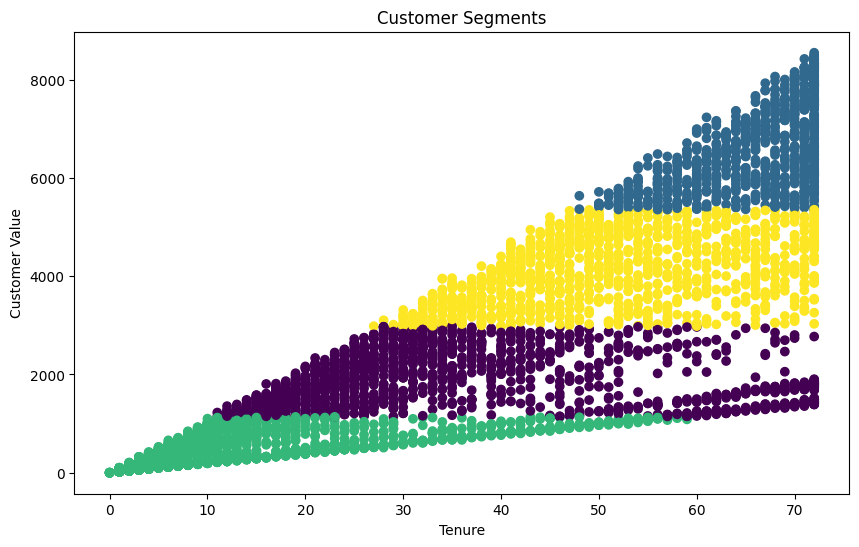

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["tenure"],
    df["CustomerValue"],
    c=df["CustomerSegment"]
)

plt.xlabel("Tenure")
plt.ylabel("Customer Value")

plt.title(
    "Customer Segments"
)

plt.show()

In [6]:
df.groupby(
    "CustomerSegment"
)[
    ["tenure",
     "MonthlyCharges",
     "CustomerValue"]
].mean()

,tenure,MonthlyCharges,CustomerValue
CustomerSegment,,,
0,36.976512,62.140458,1873.830652
1,66.204020,100.165628,6619.031809
2,11.598271,48.097487,407.910739
3,51.525799,82.203153,4098.040991


In [7]:
segment_map = {
    0:"VIP",
    1:"Regular",
    2:"New",
    3:"At Risk"
}

df["SegmentName"] = (
    df["CustomerSegment"]
    .map(segment_map)
)

df["SegmentName"].value_counts()

SegmentName
New        3124
VIP        1703
At Risk    1221
Regular     995
Name: count, dtype: int64

In [8]:
df.to_csv(
    "../data/customer_segmented.csv",
    index=False
)

print("Segmentation Saved")

Segmentation Saved
